<a href="https://colab.research.google.com/github/zzprogram/APM1111/blob/main/FA14_CURIMATMAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 [1] "Gender"   "att_high" "av_high"  "ug_high"  "att_some" "av_some" 
 [7] "ug_some"  "att_none" "av_none"  "ug_none" 


Contrasts set to contr.sum for the following variables: Gender



Anova Table (Type 3 tests)

Response: rating
                    Effect          df   MSE          F   ges p.value
1                   Gender       1, 18 42.23       0.00 <.001    .946
2                    looks 1.92, 34.62 25.50 423.73 ***  .809   <.001
3             Gender:looks 1.92, 34.62 25.50  80.43 ***  .445   <.001
4              personality 1.87, 33.62 37.89 328.25 ***  .826   <.001
5       Gender:personality 1.87, 33.62 37.89  62.45 ***  .474   <.001
6        looks:personality 3.20, 57.55 34.62  36.63 ***  .452   <.001
7 Gender:looks:personality 3.20, 57.55 34.62  24.12 ***  .352   <.001
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘+’ 0.1 ‘ ’ 1

Sphericity correction method: GG 


Plot: Three-Way Mixed

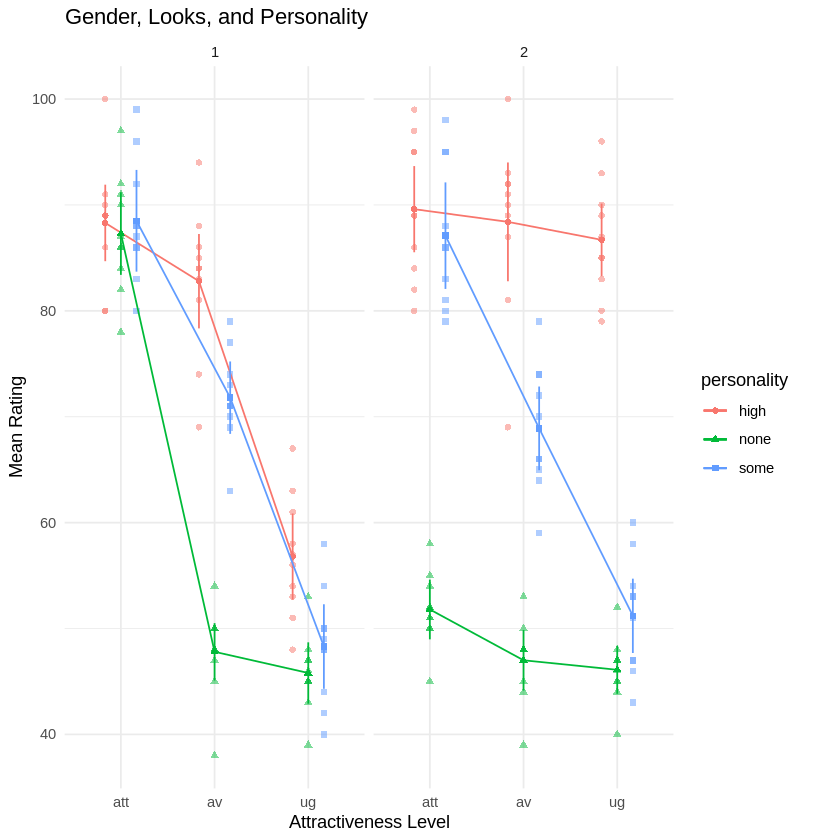

In [12]:
library(haven)     # To read .sav files
library(afex)      # For convenient ANOVA functions
library(emmeans)   # For post hoc and interactions
library(ggplot2)   # For plotting

#dataset
df <- read_sav("Looksorpersonality.sav")
print(names(df))

df$Gender <- as.factor(df$Gender)
df_long <- reshape(as.data.frame(df),
                   varying = c("att_high", "att_some", "att_none",
                               "av_high", "av_some", "av_none",
                               "ug_high", "ug_some", "ug_none"),
                   v.names = "rating",
                   timevar = "condition",
                   times = c("att_high", "att_some", "att_none",
                             "av_high", "av_some", "av_none",
                             "ug_high", "ug_some", "ug_none"),
                   direction = "long")

df_long$looks <- factor(gsub("_.*", "", df_long$condition))
df_long$personality <- factor(gsub(".*_", "", df_long$condition))

#three-way mixed anova
model <- aov_ez(id = "id",
                dv = "rating",
                data = df_long,
                between = "Gender",
                within = c("looks", "personality"))

print(model)

#plot/graph
cat("\n\nPlot: Three-Way Mixed")
afex_plot(model, x = "looks", trace = "personality", panel = "Gender",
          error = "within", mapping = c("color", "shape")) +
  theme_minimal() +
  labs(title = "Gender, Looks, and Personality",
       y = "Mean Rating", x = "Attractiveness Level")